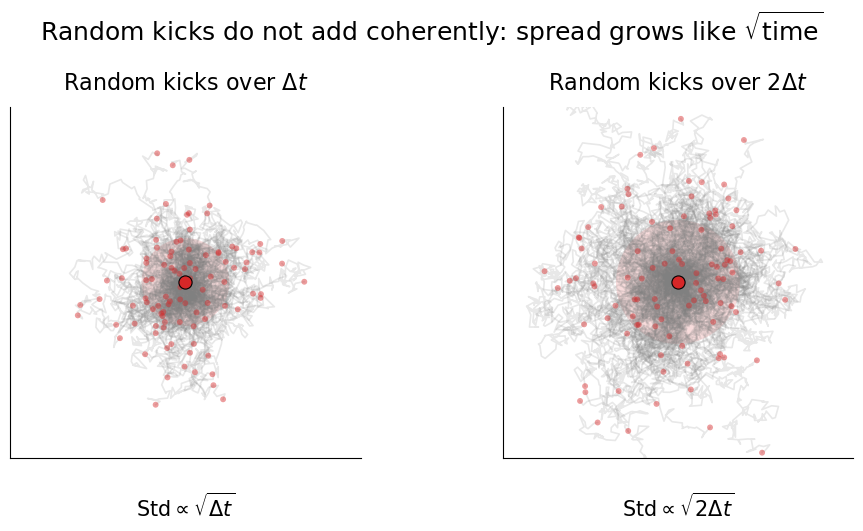

Expected per-coordinate std over Δt:   0.450
Expected per-coordinate std over 2Δt:  0.636
Expected ratio: sqrt(2) = 1.414

Empirical RMS endpoint radius over Δt:  0.673
Empirical RMS endpoint radius over 2Δt: 0.922
Empirical ratio: 1.370
Saved figure to: random_kicks_delta_t_vs_2delta_t.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Slide visual:
# Random kicks over total time Δt versus 2Δt.
#
# Goal:
# Show that random motion spreads like sqrt(time), not linearly.
#
# Noise-only dynamics:
#   x_{k+1} = x_k + g * sqrt(dt_micro) * epsilon_k
#
# where:
#   epsilon_k ~ N(0, I)
#
# Each epsilon_k is a 2D random vector.
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
RNG = np.random.default_rng(7)

N_TRAJ = 100          # number of random paths
N_MICRO = 80          # number of tiny steps used inside Δt
DELTA_T = 1.0         # base time interval
G_NOISE = 0.45        # noise strength

START = np.array([0.0, 0.0])

SAVE_FIG = True
FIG_PATH = "random_kicks_delta_t_vs_2delta_t.png"

FIGSIZE = (10, 5)
DPI = 300

X_LIM = (-1.8, 1.8)
Y_LIM = (-1.8, 1.8)

TRAJ_ALPHA = 0.18
TRAJ_LW = 1.2
ENDPOINT_SIZE = 18
START_SIZE = 90
CIRCLE_ALPHA = 0.16


# -----------------------------
# 2. Simulate random trajectories
# -----------------------------
def simulate_random_paths(total_time, n_traj=100, n_micro=80, g=0.45, start=np.array([0.0, 0.0])):
    """
    Simulate 2D noise-only random paths over a fixed total time.

    Dynamics:
        x_{k+1} = x_k + g * sqrt(dt_micro) * epsilon_k

    where:
        epsilon_k ~ N(0, I_2)

    Returns:
        paths: array of shape (n_traj, n_micro + 1, 2)
    """

    dt_micro = total_time / n_micro

    paths = np.zeros((n_traj, n_micro + 1, 2))
    paths[:, 0, :] = start[None, :]

    for k in range(n_micro):
        eps = RNG.standard_normal((n_traj, 2))  # each epsilon is a 2D random vector
        step = g * np.sqrt(dt_micro) * eps
        paths[:, k + 1, :] = paths[:, k, :] + step

    return paths


paths_dt = simulate_random_paths(
    total_time=DELTA_T,
    n_traj=N_TRAJ,
    n_micro=N_MICRO,
    g=G_NOISE,
    start=START
)

paths_2dt = simulate_random_paths(
    total_time=2 * DELTA_T,
    n_traj=N_TRAJ,
    n_micro=2 * N_MICRO,
    g=G_NOISE,
    start=START
)


# -----------------------------
# 3. Plot helper
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_random_paths(ax, paths, total_time, title):
    """
    Plot faint random trajectories and endpoint cloud.
    """

    endpoints = paths[:, -1, :]

    # Expected 1D standard deviation per coordinate:
    # Var[x_i(T)] = g^2 T, so Std = g sqrt(T)
    expected_std = G_NOISE * np.sqrt(total_time)

    # Draw expected spread circle.
    # This is not an exact confidence interval in 2D,
    # but it is visually useful for showing sqrt(time) scaling.
    circle = plt.Circle(
        START,
        expected_std,
        color="tab:red",
        alpha=CIRCLE_ALPHA,
        linewidth=0
    )
    ax.add_patch(circle)

    # Faint trajectories
    for i in range(paths.shape[0]):
        ax.plot(
            paths[i, :, 0],
            paths[i, :, 1],
            color="gray",
            alpha=TRAJ_ALPHA,
            lw=TRAJ_LW
        )

    # Endpoints
    ax.scatter(
        endpoints[:, 0],
        endpoints[:, 1],
        s=ENDPOINT_SIZE,
        color="tab:red",
        alpha=0.45,
        edgecolor="none",
        zorder=3
    )

    # Start point
    ax.scatter(
        START[0],
        START[1],
        s=START_SIZE,
        color="tab:red",
        edgecolor="black",
        linewidth=0.8,
        zorder=4
    )

    ax.set_title(title, fontsize=16, pad=12)
    clean_axes(ax)

    return endpoints, expected_std


# -----------------------------
# 4. Create figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

end_dt, std_dt = plot_random_paths(
    axes[0],
    paths_dt,
    total_time=DELTA_T,
    title=r"Random kicks over $\Delta t$"
)

end_2dt, std_2dt = plot_random_paths(
    axes[1],
    paths_2dt,
    total_time=2 * DELTA_T,
    title=r"Random kicks over $2\Delta t$"
)

# Add clean equations under each panel
axes[0].text(
    0.5,
    -0.10,
    r"$\mathrm{Std} \propto \sqrt{\Delta t}$",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=15
)

axes[1].text(
    0.5,
    -0.10,
    r"$\mathrm{Std} \propto \sqrt{2\Delta t}$",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=15
)

fig.suptitle(
    r"Random kicks do not add coherently: spread grows like $\sqrt{\mathrm{time}}$",
    fontsize=18,
    y=1.02
)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig(FIG_PATH, dpi=DPI, bbox_inches="tight")

plt.show()


# -----------------------------
# 5. Print sanity check
# -----------------------------
empirical_std_dt = np.sqrt(np.mean(np.sum((end_dt - START[None, :])**2, axis=1)))
empirical_std_2dt = np.sqrt(np.mean(np.sum((end_2dt - START[None, :])**2, axis=1)))

print(f"Expected per-coordinate std over Δt:   {std_dt:.3f}")
print(f"Expected per-coordinate std over 2Δt:  {std_2dt:.3f}")
print(f"Expected ratio: sqrt(2) = {np.sqrt(2):.3f}")
print()
print(f"Empirical RMS endpoint radius over Δt:  {empirical_std_dt:.3f}")
print(f"Empirical RMS endpoint radius over 2Δt: {empirical_std_2dt:.3f}")
print(f"Empirical ratio: {empirical_std_2dt / empirical_std_dt:.3f}")

if SAVE_FIG:
    print(f"Saved figure to: {FIG_PATH}")

# SDE forward, Eurler maruyama:

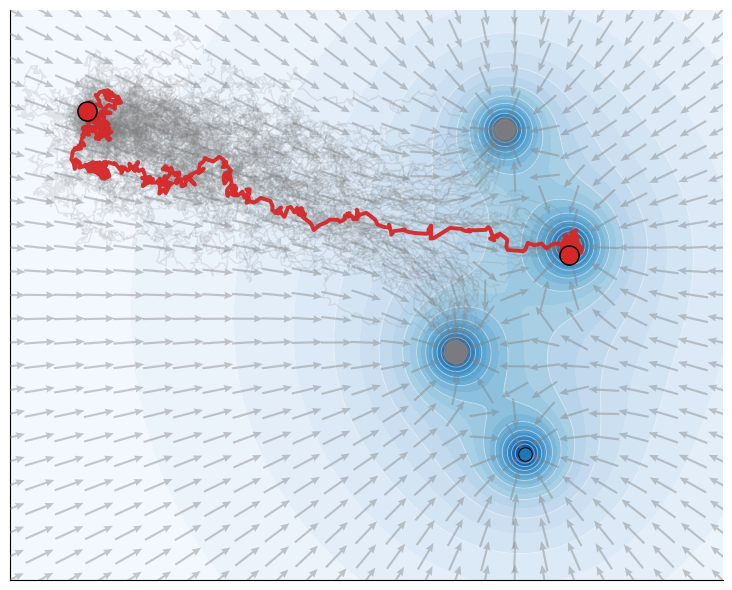

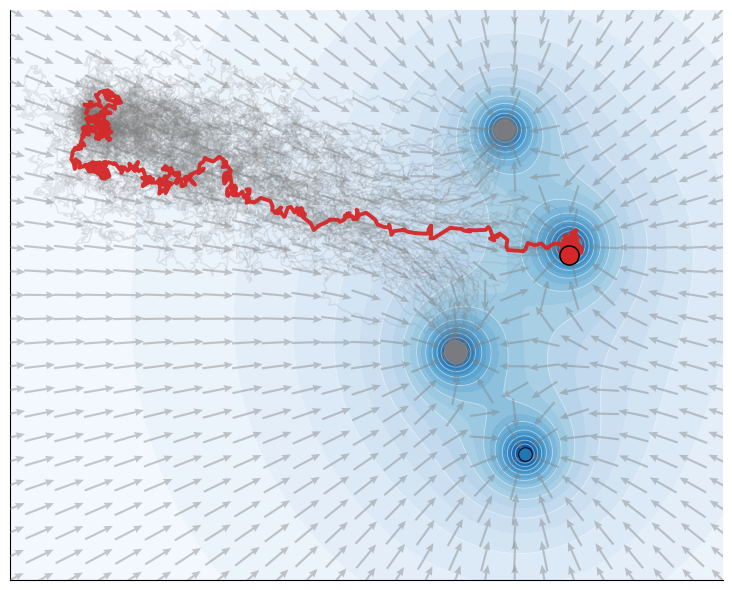

Euler-Maruyama SDE simulation
Update: x[n+1] = x[n] + Δt F(x[n]) + σ sqrt(Δt) ε[n]
ε[n] ~ N(0, I_2)
DT = 0.015
SIGMA_NOISE = 0.22
N_TRAJ = 80
N_STEPS = 900
Saved static figure to: slide_sde_euler_maruyama_static.png
Saved animation GIF to: slide_sde_euler_maruyama_motion.gif


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Slide: From noisy update to an SDE
#
# Simulation of noisy overdamped motion:
#
#   x_{n+1} = x_n + Δt F(x_n) + σ sqrt(Δt) ε_n
#
# where:
#
#   ε_n ~ N(0, I_2)
#
# This is the Euler-Maruyama method.
#
# The figure shows:
#   - fixed negative source charges
#   - potential landscape
#   - force field arrows
#   - many faint stochastic trajectories
#   - one highlighted red stochastic trajectory
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
RNG = np.random.default_rng(7)

# Source-charge configuration
N_SOURCE_CHARGES = 4
SOURCE_SHAPE = "S"              # "S" or "triangle"
SOURCE_CENTER = np.array([1.25, 0.0])

# Particle initial condition
START_POS = np.array([-2.35, 1.55])

# SDE dynamics
DT = 0.015
N_STEPS = 900
SIGMA_NOISE = 0.22              # σ: noise strength
K_COULOMB = 1.0
SOFTENING_FORCE = 0.14
SOFTENING_POTENTIAL = 0.12
MAX_DRIFT_SPEED = 2.0
Q_SOURCE = -1.0

# Number of stochastic simulations
N_TRAJ = 80                     # faint trajectories
HIGHLIGHT_TRAJ_INDEX = 0        # red trajectory

# Plot limits
X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

# Potential grid resolution
NX = 300
NY = 240

# Arrow grid resolution
NQX = 25
NQY = 25

# Arrow appearance
ARROW_COLOR = "grey"
ARROW_ALPHA = 0.42
ARROW_WIDTH = 0.003
ARROW_LENGTH = 0.26
ARROW_HEADWIDTH = 3.5
ARROW_HEADLENGTH = 4.2
ARROW_HEADAXISLENGTH = 3.8
ARROW_NORMALIZE = True

# Trajectory appearance
FAINT_TRAJ_COLOR = "gray"
FAINT_TRAJ_ALPHA = 0.16
FAINT_TRAJ_LW = 1.0

HIGHLIGHT_COLOR = "tab:red"
HIGHLIGHT_LW = 2.8
HIGHLIGHT_DOT_SIZE = 190

SOURCE_SIZE = 95
START_SIZE = 190

# Animation
N_FRAMES = 180
FPS = 25

# Saving
SAVE_STATIC_PNG = True
SAVE_ANIMATION_GIF = True

STATIC_PNG_PATH = "slide_sde_euler_maruyama_static.png"
ANIMATION_GIF_PATH = "slide_sde_euler_maruyama_motion.gif"


# -----------------------------
# 2. Build source charges
# -----------------------------
def make_source_charges(shape="S", n=4, center=np.array([1.25, 0.0])):
    """
    Create fixed negative source charges.
    """

    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)
        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi
        charges = np.stack([x, y], axis=1)
        charges += 0.035 * RNG.standard_normal((n, 2))

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([ 0.65, -0.95])
        C = np.array([ 0.00,  0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * RNG.standard_normal((n, 2))

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    return charges + center[None, :]


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Force field
# -----------------------------
def force_on_positive_charge(x, source_positions):
    """
    Total attractive force on a positive test charge at x
    due to fixed negative source charges.

    x can be shape (2,) or (B, 2).
    """

    x = np.asarray(x)

    if x.ndim == 1:
        r = source_positions - x[None, :]
        dist2 = np.sum(r**2, axis=1) + SOFTENING_FORCE**2
        dist3 = dist2 ** 1.5
        forces = K_COULOMB * r / dist3[:, None]
        F = np.sum(forces, axis=0)
        return F

    elif x.ndim == 2:
        # x shape: (B, 2)
        # source_positions shape: (M, 2)
        r = source_positions[None, :, :] - x[:, None, :]
        dist2 = np.sum(r**2, axis=2) + SOFTENING_FORCE**2
        dist3 = dist2 ** 1.5
        forces = K_COULOMB * r / dist3[:, :, None]
        F = np.sum(forces, axis=1)
        return F

    else:
        raise ValueError("x must have shape (2,) or (B, 2)")


def cap_drift(F, max_speed=2.0):
    """
    Cap deterministic drift speed for numerical stability.
    Works for F shape (2,) or (B, 2).
    """

    F = np.asarray(F)

    if F.ndim == 1:
        speed = np.linalg.norm(F)
        if speed > max_speed:
            F = F / speed * max_speed
        return F

    speeds = np.linalg.norm(F, axis=1, keepdims=True)
    scale = np.minimum(1.0, max_speed / (speeds + 1e-12))
    return F * scale


# -----------------------------
# 4. Euler-Maruyama simulation
# -----------------------------
def simulate_sde_paths(n_traj=80,
                       n_steps=900,
                       dt=0.015,
                       sigma=0.22,
                       start_pos=np.array([-2.35, 1.55])):
    """
    Simulate many SDE trajectories using Euler-Maruyama:

        x_{n+1} = x_n + Δt F(x_n) + σ sqrt(Δt) ε_n

    where:

        ε_n ~ N(0, I_2)
    """

    paths = np.zeros((n_traj, n_steps + 1, 2))
    paths[:, 0, :] = start_pos[None, :]

    for n in range(n_steps):
        x = paths[:, n, :]

        F = force_on_positive_charge(x, source_pos)
        F = cap_drift(F, MAX_DRIFT_SPEED)

        eps = RNG.standard_normal((n_traj, 2))
        noise_step = sigma * np.sqrt(dt) * eps

        paths[:, n + 1, :] = x + dt * F + noise_step

    return paths


paths = simulate_sde_paths(
    n_traj=N_TRAJ,
    n_steps=N_STEPS,
    dt=DT,
    sigma=SIGMA_NOISE,
    start_pos=START_POS
)

highlight_path = paths[HIGHLIGHT_TRAJ_INDEX]


# -----------------------------
# 5. Potential grid
# -----------------------------
def compute_potential_grid(source_positions,
                           q_source=-1.0,
                           k_coulomb=1.0,
                           eps=0.12,
                           xlim=(-3.0, 3.0),
                           ylim=(-2.4, 2.4),
                           nx=300,
                           ny=240):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    phi = np.zeros_like(X, dtype=float)

    for i in range(source_positions.shape[0]):
        dx = X - source_positions[i, 0]
        dy = Y - source_positions[i, 1]
        dist = np.sqrt(dx**2 + dy**2 + eps**2)
        phi += k_coulomb * q_source / dist

    return X, Y, phi


Xg, Yg, phi = compute_potential_grid(
    source_positions=source_pos,
    q_source=Q_SOURCE,
    k_coulomb=K_COULOMB,
    eps=SOFTENING_POTENTIAL,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NX,
    ny=NY
)

# Negative charges produce negative potential.
# Plot -phi so strong attractive regions appear darker.
phi_display = -phi


# -----------------------------
# 6. Force field grid for arrows
# -----------------------------
def compute_force_field_grid(source_positions,
                             xlim=(-3.0, 3.0),
                             ylim=(-2.4, 2.4),
                             nx=25,
                             ny=25,
                             normalize=True):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(ny):
        for j in range(nx):
            pos = np.array([X[i, j], Y[i, j]])
            F = force_on_positive_charge(pos, source_positions)

            if normalize:
                nrm = np.linalg.norm(F)
                if nrm > 1e-10:
                    F = F / nrm

            U[i, j] = F[0]
            V[i, j] = F[1]

    return X, Y, U, V


Xq, Yq, Uq, Vq = compute_force_field_grid(
    source_positions=source_pos,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NQX,
    ny=NQY,
    normalize=ARROW_NORMALIZE
)

Uq_plot = ARROW_LENGTH * Uq
Vq_plot = ARROW_LENGTH * Vq


# -----------------------------
# 7. Plot helpers
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_background(ax):
    ax.contourf(Xg, Yg, phi_display, levels=30, cmap="Blues")
    ax.contour(
        Xg,
        Yg,
        phi_display,
        levels=12,
        colors="white",
        linewidths=0.6,
        alpha=0.55
    )

    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=SOURCE_SIZE,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7,
        zorder=4
    )

    ax.quiver(
        Xq,
        Yq,
        Uq_plot,
        Vq_plot,
        color=ARROW_COLOR,
        alpha=ARROW_ALPHA,
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=ARROW_WIDTH,
        headwidth=ARROW_HEADWIDTH,
        headlength=ARROW_HEADLENGTH,
        headaxislength=ARROW_HEADAXISLENGTH,
        zorder=3
    )

    clean_axes(ax)


# -----------------------------
# 8. Static plot
# -----------------------------
def plot_static_sde_paths():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    # Faint stochastic trajectories
    for i in range(N_TRAJ):
        ax.plot(
            paths[i, :, 0],
            paths[i, :, 1],
            color=FAINT_TRAJ_COLOR,
            alpha=FAINT_TRAJ_ALPHA,
            lw=FAINT_TRAJ_LW,
            zorder=5
        )

    # Highlight one trajectory
    ax.plot(
        highlight_path[:, 0],
        highlight_path[:, 1],
        color=HIGHLIGHT_COLOR,
        alpha=0.95,
        lw=HIGHLIGHT_LW,
        zorder=6
    )

    ax.scatter(
        START_POS[0],
        START_POS[1],
        s=START_SIZE,
        c=HIGHLIGHT_COLOR,
        edgecolor="black",
        linewidth=1.1,
        zorder=7
    )

    ax.scatter(
        highlight_path[-1, 0],
        highlight_path[-1, 1],
        s=HIGHLIGHT_DOT_SIZE,
        c=HIGHLIGHT_COLOR,
        edgecolor="black",
        linewidth=1.1,
        zorder=8
    )

    plt.tight_layout()

    if SAVE_STATIC_PNG:
        plt.savefig(STATIC_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_static_sde_paths()


# -----------------------------
# 9. Animation
# -----------------------------
def animate_sde_paths():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    # Lines for faint trajectories
    faint_lines = []
    for _ in range(N_TRAJ):
        line, = ax.plot(
            [],
            [],
            color=FAINT_TRAJ_COLOR,
            alpha=FAINT_TRAJ_ALPHA,
            lw=FAINT_TRAJ_LW,
            zorder=5
        )
        faint_lines.append(line)

    # Highlight trajectory
    highlight_line, = ax.plot(
        [],
        [],
        color=HIGHLIGHT_COLOR,
        alpha=0.95,
        lw=HIGHLIGHT_LW,
        zorder=6
    )

    highlight_dot = ax.scatter(
        [],
        [],
        s=HIGHLIGHT_DOT_SIZE,
        c=HIGHLIGHT_COLOR,
        edgecolor="black",
        linewidth=1.1,
        zorder=8
    )

    frame_ids = np.linspace(0, N_STEPS, N_FRAMES).astype(int)

    def init():
        for line in faint_lines:
            line.set_data([], [])

        highlight_line.set_data([], [])
        highlight_dot.set_offsets(np.array([[START_POS[0], START_POS[1]]]))

        return faint_lines + [highlight_line, highlight_dot]

    def update(frame_idx):
        idx = frame_ids[frame_idx]

        for i, line in enumerate(faint_lines):
            line.set_data(
                paths[i, :idx + 1, 0],
                paths[i, :idx + 1, 1]
            )

        highlight_line.set_data(
            highlight_path[:idx + 1, 0],
            highlight_path[:idx + 1, 1]
        )

        highlight_dot.set_offsets(
            np.array([[highlight_path[idx, 0], highlight_path[idx, 1]]])
        )

        return faint_lines + [highlight_line, highlight_dot]

    anim = FuncAnimation(
        fig,
        update,
        frames=N_FRAMES,
        init_func=init,
        interval=35,
        blit=True
    )

    plt.tight_layout()

    if SAVE_ANIMATION_GIF:
        anim.save(ANIMATION_GIF_PATH, writer=PillowWriter(fps=FPS))

    plt.show()

    return anim


anim = animate_sde_paths()


# -----------------------------
# 10. Print info
# -----------------------------
print("Euler-Maruyama SDE simulation")
print(f"Update: x[n+1] = x[n] + Δt F(x[n]) + σ sqrt(Δt) ε[n]")
print(f"ε[n] ~ N(0, I_2)")
print(f"DT = {DT}")
print(f"SIGMA_NOISE = {SIGMA_NOISE}")
print(f"N_TRAJ = {N_TRAJ}")
print(f"N_STEPS = {N_STEPS}")

if SAVE_STATIC_PNG:
    print(f"Saved static figure to: {STATIC_PNG_PATH}")

if SAVE_ANIMATION_GIF:
    print(f"Saved animation GIF to: {ANIMATION_GIF_PATH}")

# one initial point→many noisy paths


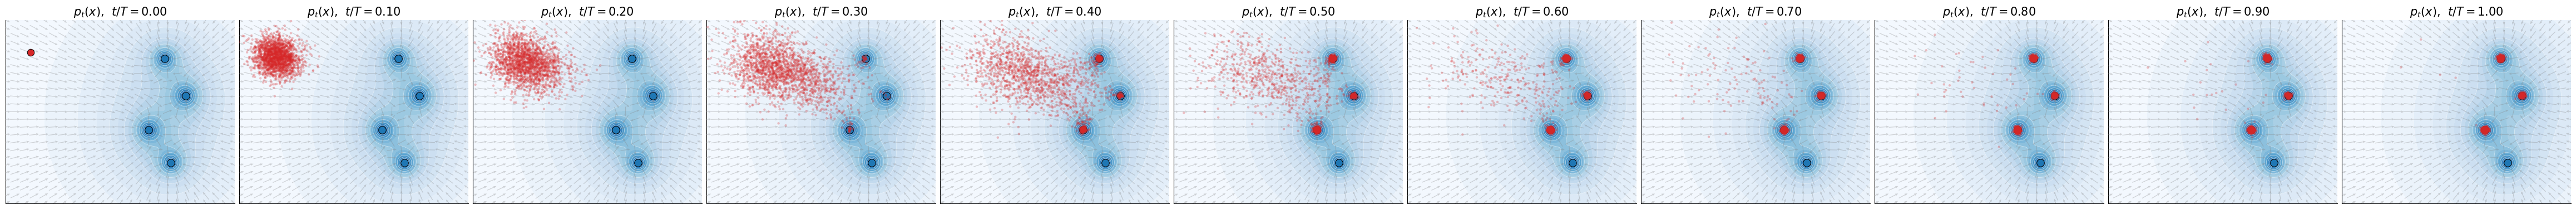

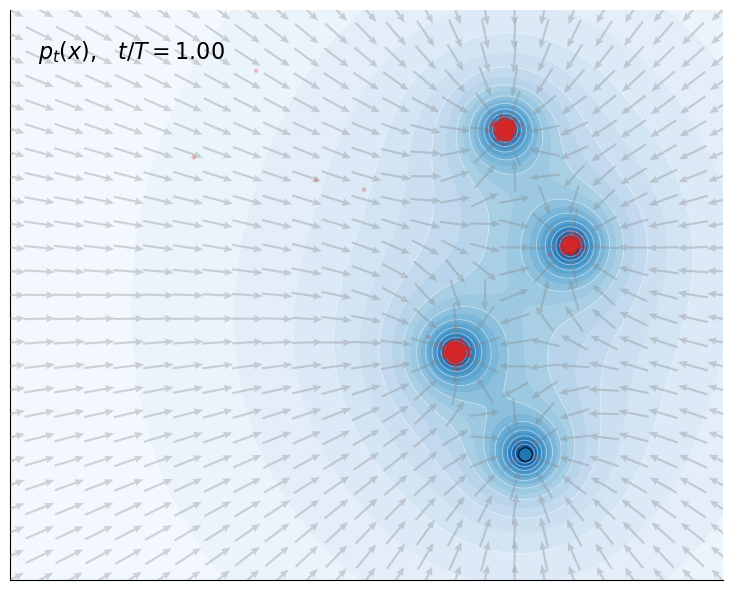

Many-particle SDE simulation
Concept: x_t is random, so we describe the cloud by p_t(x).
N_PARTICLES = 1900
N_STEPS = 900
DT = 0.015
SIGMA_NOISE = 0.24
Saved snapshot figure to: slide_density_snapshots_cloud_only.png
Saved animation GIF to: slide_density_evolution_cloud_only.gif


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Slide:
# From noisy trajectories to a probability density
#
# Same physical system as before:
#   - fixed negative source charges
#   - potential landscape
#   - force field
#
# But now we simulate MANY noisy particles starting from the SAME x0.
#
# Euler-Maruyama update:
#
#   x_{n+1} = x_n + Δt F(x_n) + σ sqrt(Δt) ε_n
#
# where:
#
#   ε_n ~ N(0, I_2)
#
# Conceptual message:
#   individual trajectories are noisy;
#   the better object is the evolving cloud / density p_t(x).
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
RNG = np.random.default_rng(7)

# Source-charge configuration
N_SOURCE_CHARGES = 4
SOURCE_SHAPE = "S"              # "S" or "triangle"
SOURCE_CENTER = np.array([1.25, 0.0])

# Initial condition for all particles
START_POS = np.array([-2.35, 1.55])

# SDE dynamics
DT = 0.015
N_STEPS = 900
SIGMA_NOISE = 0.24              # noise strength
K_COULOMB = 1.0
SOFTENING_FORCE = 0.14
SOFTENING_POTENTIAL = 0.12
MAX_DRIFT_SPEED = 2.0
Q_SOURCE = -1.0

# Number of particles
N_PARTICLES = 1900

# Plot limits
X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

# Potential grid resolution
NX = 300
NY = 240

# Arrow grid resolution
NQX = 25
NQY = 25

# Arrow appearance
ARROW_COLOR = "grey"
ARROW_ALPHA = 0.32
ARROW_WIDTH = 0.003
ARROW_LENGTH = 0.26
ARROW_HEADWIDTH = 3.5
ARROW_HEADLENGTH = 4.2
ARROW_HEADAXISLENGTH = 3.8
ARROW_NORMALIZE = True

# Particle cloud appearance
PARTICLE_SIZE = 10
PARTICLE_ALPHA = 0.28
PARTICLE_COLOR = "tab:red"

SOURCE_SIZE = 95
START_MARKER_SIZE = 80

# Snapshot settings
SNAPSHOT_FRACTIONS = [0.0, 0.10, 0.20, 0.30, 0.40, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Animation settings
N_FRAMES = 170
FPS = 25

# Saving
SAVE_SNAPSHOT_PNG = True
SAVE_ANIMATION_GIF = True

SNAPSHOT_PNG_PATH = "slide_density_snapshots_cloud_only.png"
ANIMATION_GIF_PATH = "slide_density_evolution_cloud_only.gif"


# -----------------------------
# 2. Build source charges
# -----------------------------
def make_source_charges(shape="S", n=4, center=np.array([1.25, 0.0])):
    """
    Create fixed negative source charges.
    """

    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)
        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi
        charges = np.stack([x, y], axis=1)
        charges += 0.035 * RNG.standard_normal((n, 2))

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([0.65, -0.95])
        C = np.array([0.00, 0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * RNG.standard_normal((n, 2))

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    return charges + center[None, :]


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Force field
# -----------------------------
def force_on_positive_charge(x, source_positions):
    """
    Total attractive force on positive test charge(s).

    x can be:
        shape (2,)
        shape (B, 2)
    """

    x = np.asarray(x)

    if x.ndim == 1:
        r = source_positions - x[None, :]
        dist2 = np.sum(r**2, axis=1) + SOFTENING_FORCE**2
        dist3 = dist2 ** 1.5
        forces = K_COULOMB * r / dist3[:, None]
        return np.sum(forces, axis=0)

    if x.ndim == 2:
        r = source_positions[None, :, :] - x[:, None, :]
        dist2 = np.sum(r**2, axis=2) + SOFTENING_FORCE**2
        dist3 = dist2 ** 1.5
        forces = K_COULOMB * r / dist3[:, :, None]
        return np.sum(forces, axis=1)

    raise ValueError("x must have shape (2,) or (B, 2)")


def cap_drift(F, max_speed=2.0):
    """
    Cap deterministic drift for numerical stability.
    """

    F = np.asarray(F)

    if F.ndim == 1:
        speed = np.linalg.norm(F)
        if speed > max_speed:
            return F / speed * max_speed
        return F

    speeds = np.linalg.norm(F, axis=1, keepdims=True)
    scale = np.minimum(1.0, max_speed / (speeds + 1e-12))
    return F * scale


# -----------------------------
# 4. Simulate many noisy particles
# -----------------------------
def simulate_sde_particles(n_particles=900,
                           n_steps=900,
                           dt=0.015,
                           sigma=0.24,
                           start_pos=np.array([-2.35, 1.55])):
    """
    Euler-Maruyama simulation:

        x_{n+1} = x_n + Δt F(x_n) + σ sqrt(Δt) ε_n

    All particles start at the same x0.
    Different particles receive different noise.
    """

    paths = np.zeros((n_particles, n_steps + 1, 2))
    paths[:, 0, :] = start_pos[None, :]

    for n in range(n_steps):
        x = paths[:, n, :]

        F = force_on_positive_charge(x, source_pos)
        F = cap_drift(F, MAX_DRIFT_SPEED)

        eps = RNG.standard_normal((n_particles, 2))
        noise = sigma * np.sqrt(dt) * eps

        paths[:, n + 1, :] = x + dt * F + noise

    return paths


paths = simulate_sde_particles(
    n_particles=N_PARTICLES,
    n_steps=N_STEPS,
    dt=DT,
    sigma=SIGMA_NOISE,
    start_pos=START_POS
)


# -----------------------------
# 5. Potential grid
# -----------------------------
def compute_potential_grid(source_positions,
                           q_source=-1.0,
                           k_coulomb=1.0,
                           eps=0.12,
                           xlim=(-3.0, 3.0),
                           ylim=(-2.4, 2.4),
                           nx=300,
                           ny=240):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    phi = np.zeros_like(X, dtype=float)

    for i in range(source_positions.shape[0]):
        dx = X - source_positions[i, 0]
        dy = Y - source_positions[i, 1]
        dist = np.sqrt(dx**2 + dy**2 + eps**2)
        phi += k_coulomb * q_source / dist

    return X, Y, phi


Xg, Yg, phi = compute_potential_grid(
    source_positions=source_pos,
    q_source=Q_SOURCE,
    k_coulomb=K_COULOMB,
    eps=SOFTENING_POTENTIAL,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NX,
    ny=NY
)

# Negative charges produce negative phi.
# We plot -phi so attractive wells look darker.
phi_display = -phi


# -----------------------------
# 6. Force field grid for arrows
# -----------------------------
def compute_force_field_grid(source_positions,
                             xlim=(-3.0, 3.0),
                             ylim=(-2.4, 2.4),
                             nx=25,
                             ny=25,
                             normalize=True):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(ny):
        for j in range(nx):
            pos = np.array([X[i, j], Y[i, j]])
            F = force_on_positive_charge(pos, source_positions)

            if normalize:
                norm = np.linalg.norm(F)
                if norm > 1e-10:
                    F = F / norm

            U[i, j] = F[0]
            V[i, j] = F[1]

    return X, Y, U, V


Xq, Yq, Uq, Vq = compute_force_field_grid(
    source_positions=source_pos,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NQX,
    ny=NQY,
    normalize=ARROW_NORMALIZE
)

Uq_plot = ARROW_LENGTH * Uq
Vq_plot = ARROW_LENGTH * Vq


# -----------------------------
# 7. Plot helpers
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_background(ax):
    ax.contourf(
        Xg,
        Yg,
        phi_display,
        levels=30,
        cmap="Blues"
    )

    ax.contour(
        Xg,
        Yg,
        phi_display,
        levels=12,
        colors="white",
        linewidths=0.6,
        alpha=0.55
    )

    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=SOURCE_SIZE,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7,
        zorder=4
    )

    ax.quiver(
        Xq,
        Yq,
        Uq_plot,
        Vq_plot,
        color=ARROW_COLOR,
        alpha=ARROW_ALPHA,
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=ARROW_WIDTH,
        headwidth=ARROW_HEADWIDTH,
        headlength=ARROW_HEADLENGTH,
        headaxislength=ARROW_HEADAXISLENGTH,
        zorder=3
    )

    clean_axes(ax)


# -----------------------------
# 8. Static snapshot figure
# -----------------------------
def plot_density_snapshots():
    snapshot_ids = [int(frac * N_STEPS) for frac in SNAPSHOT_FRACTIONS]

    fig, axes = plt.subplots(
        1,
        len(snapshot_ids),
        figsize=(4.2 * len(snapshot_ids), 4.2),
        constrained_layout=True
    )

    if len(snapshot_ids) == 1:
        axes = [axes]

    for ax, idx, frac in zip(axes, snapshot_ids, SNAPSHOT_FRACTIONS):
        draw_background(ax)

        cloud = paths[:, idx, :]

        ax.scatter(
            cloud[:, 0],
            cloud[:, 1],
            s=PARTICLE_SIZE,
            c=PARTICLE_COLOR,
            alpha=PARTICLE_ALPHA,
            edgecolor="none",
            zorder=5
        )

        # Small marker only at t=0 to show the shared initial condition.
        # No individual highlighted trajectory.
        if idx == 0:
            ax.scatter(
                START_POS[0],
                START_POS[1],
                s=START_MARKER_SIZE,
                c=PARTICLE_COLOR,
                edgecolor="black",
                linewidth=0.7,
                zorder=6
            )

        ax.set_title(
            rf"$p_t(x)$,  $t/T={frac:.2f}$",
            fontsize=15
        )

    if SAVE_SNAPSHOT_PNG:
        plt.savefig(SNAPSHOT_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_density_snapshots()


# -----------------------------
# 9. Animation
# -----------------------------
def animate_density_evolution():
    fig, ax = plt.subplots(figsize=(8, 6))

    draw_background(ax)

    cloud_scatter = ax.scatter(
        paths[:, 0, 0],
        paths[:, 0, 1],
        s=PARTICLE_SIZE,
        c=PARTICLE_COLOR,
        alpha=PARTICLE_ALPHA,
        edgecolor="none",
        zorder=5
    )

    time_text = ax.text(
        0.04,
        0.95,
        r"$p_0(x)$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        color="black"
    )

    frame_ids = np.linspace(0, N_STEPS, N_FRAMES).astype(int)

    def update(frame_idx):
        idx = frame_ids[frame_idx]

        cloud_scatter.set_offsets(paths[:, idx, :])
        time_text.set_text(rf"$p_t(x)$,   $t/T={idx / N_STEPS:.2f}$")

        return cloud_scatter, time_text

    anim = FuncAnimation(
        fig,
        update,
        frames=N_FRAMES,
        interval=35,
        blit=True
    )

    plt.tight_layout()

    if SAVE_ANIMATION_GIF:
        anim.save(ANIMATION_GIF_PATH, writer=PillowWriter(fps=FPS))

    plt.show()

    return anim


anim = animate_density_evolution()


# -----------------------------
# 10. Print info
# -----------------------------
print("Many-particle SDE simulation")
print("Concept: x_t is random, so we describe the cloud by p_t(x).")
print(f"N_PARTICLES = {N_PARTICLES}")
print(f"N_STEPS = {N_STEPS}")
print(f"DT = {DT}")
print(f"SIGMA_NOISE = {SIGMA_NOISE}")

if SAVE_SNAPSHOT_PNG:
    print(f"Saved snapshot figure to: {SNAPSHOT_PNG_PATH}")

if SAVE_ANIMATION_GIF:
    print(f"Saved animation GIF to: {ANIMATION_GIF_PATH}")

# Pure diffusion movie code


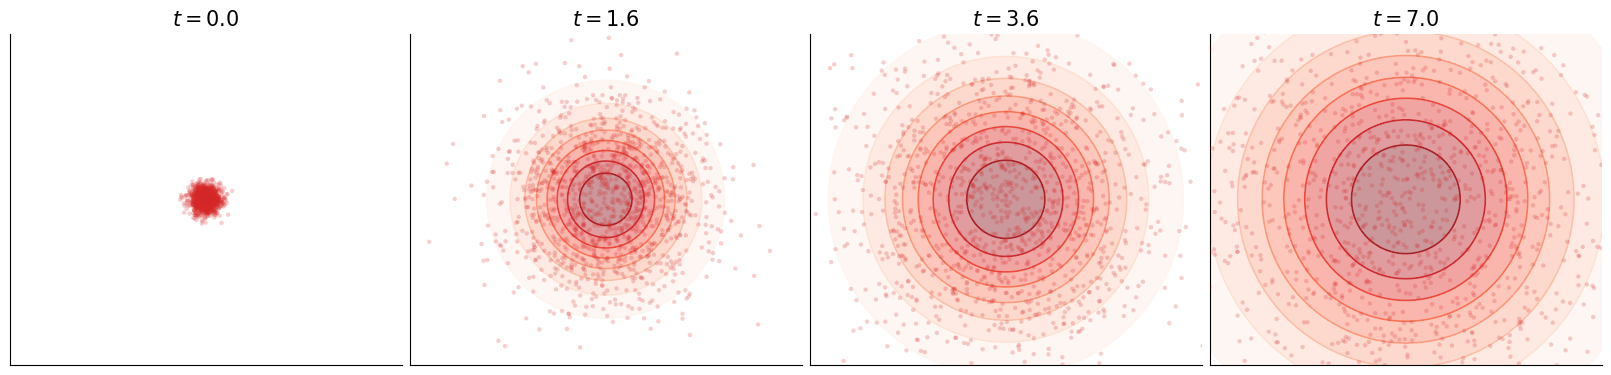

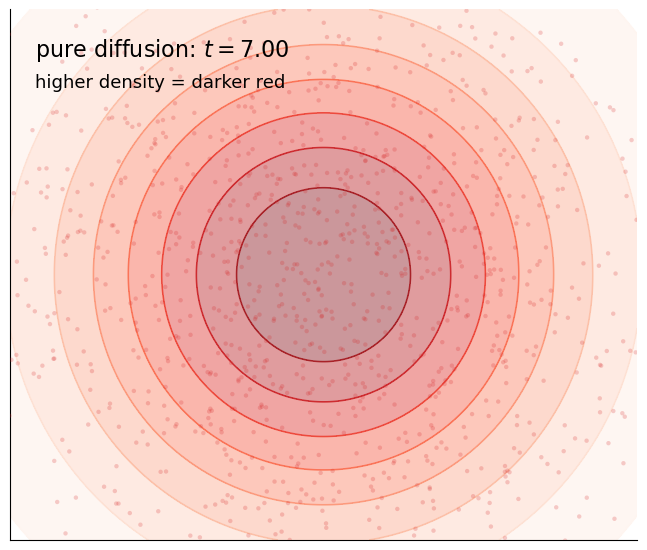

Pure diffusion simulation with density contours
Update: x[n+1] = x[n] + sigma * sqrt(dt) * epsilon[n]
epsilon[n] ~ N(0, I_2)
N_PARTICLES = 1200
DT = 0.02
N_STEPS = 350
SIGMA = 0.55
Saved snapshot figure to: pure_diffusion_snapshots_with_density.png
Saved animation GIF to: pure_diffusion_movie_with_density.gif


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Pure diffusion movie with density contours
#
# No force field:
#   F(x) = 0
#
# Update:
#   x_{n+1} = x_n + sigma * sqrt(dt) * epsilon_n
#
# where:
#   epsilon_n ~ N(0, I_2)
#
# Concept:
#   particles spread from high-density regions to low-density regions.
#
# This version also shows density contours using the closed-form
# Gaussian density of pure diffusion.
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
RNG = np.random.default_rng(10)

N_PARTICLES = 1200

DT = 0.02
N_STEPS = 350
SIGMA = 0.55

# Initial particle cloud
START_CENTER = np.array([0.0, 0.0])
START_STD = 0.10

# Plot limits
X_LIM = (-2.6, 2.6)
Y_LIM = (-2.2, 2.2)

# Particle appearance
PARTICLE_SIZE = 10
PARTICLE_ALPHA = 0.22
PARTICLE_COLOR = "tab:red"

# Density contour settings
SHOW_DENSITY = True
DENSITY_CMAP = "Reds"
DENSITY_ALPHA = 0.42
N_DENSITY_LEVELS = 9
DENSITY_LINE_ALPHA = 0.75
DENSITY_LINE_WIDTH = 1.2

# Grid for density contours
NX = 250
NY = 220

# Animation
N_FRAMES = 160
FPS = 25

# Saving
SAVE_SNAPSHOT_PNG = True
SAVE_ANIMATION_GIF = True

SNAPSHOT_PNG_PATH = "pure_diffusion_snapshots_with_density.png"
ANIMATION_GIF_PATH = "pure_diffusion_movie_with_density.gif"

SNAPSHOT_STEPS = [0, 80, 180, 350]


# -----------------------------
# 2. Simulate pure diffusion
# -----------------------------
def simulate_pure_diffusion(
    n_particles=1200,
    n_steps=350,
    dt=0.02,
    sigma=0.55,
    start_center=np.array([0.0, 0.0]),
    start_std=0.10,
):
    """
    Simulate pure 2D diffusion:

        x_{n+1} = x_n + sigma * sqrt(dt) * epsilon_n

    where:

        epsilon_n ~ N(0, I_2)
    """

    paths = np.zeros((n_particles, n_steps + 1, 2))

    # Start as a small dense Gaussian blob.
    paths[:, 0, :] = (
        start_center[None, :]
        + start_std * RNG.standard_normal((n_particles, 2))
    )

    for n in range(n_steps):
        eps = RNG.standard_normal((n_particles, 2))
        noise_step = sigma * np.sqrt(dt) * eps
        paths[:, n + 1, :] = paths[:, n, :] + noise_step

    return paths


paths = simulate_pure_diffusion(
    n_particles=N_PARTICLES,
    n_steps=N_STEPS,
    dt=DT,
    sigma=SIGMA,
    start_center=START_CENTER,
    start_std=START_STD,
)


# -----------------------------
# 3. Density grid
# -----------------------------
xs = np.linspace(X_LIM[0], X_LIM[1], NX)
ys = np.linspace(Y_LIM[0], Y_LIM[1], NY)
Xg, Yg = np.meshgrid(xs, ys)


def theoretical_std(step_idx):
    """
    Per-coordinate standard deviation at time t.

    Initial variance:
        START_STD^2

    Diffusion variance added:
        SIGMA^2 * t

    where:
        t = step_idx * DT
    """

    t = step_idx * DT
    return np.sqrt(START_STD**2 + SIGMA**2 * t)


def gaussian_density_grid(step_idx):
    """
    Closed-form density of the diffusion cloud.

    Since the initial condition is Gaussian and the noise is Gaussian,
    the density remains Gaussian:

        p_t(x) = N(START_CENTER, std(t)^2 I)
    """

    std = theoretical_std(step_idx)
    var = std**2

    dx = Xg - START_CENTER[0]
    dy = Yg - START_CENTER[1]
    r2 = dx**2 + dy**2

    density = np.exp(-0.5 * r2 / var) / (2.0 * np.pi * var)

    # Normalize for stable plotting across time.
    density = density / density.max()

    return density


def density_levels():
    """
    Use levels away from zero so the whole background does not become red.
    """

    return np.linspace(0.08, 1.0, N_DENSITY_LEVELS)


# -----------------------------
# 4. Plot helpers
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_density(ax, step_idx):
    """
    Draw filled density contours and contour lines.
    """

    if not SHOW_DENSITY:
        return

    density = gaussian_density_grid(step_idx)
    levels = density_levels()

    ax.contourf(
        Xg,
        Yg,
        density,
        levels=levels,
        cmap=DENSITY_CMAP,
        alpha=DENSITY_ALPHA,
        zorder=1,
    )

    ax.contour(
        Xg,
        Yg,
        density,
        levels=levels,
        cmap=DENSITY_CMAP,
        linewidths=DENSITY_LINE_WIDTH,
        alpha=DENSITY_LINE_ALPHA,
        zorder=2,
    )


# -----------------------------
# 5. Static snapshot figure
# -----------------------------
def plot_snapshots():
    fig, axes = plt.subplots(
        1,
        len(SNAPSHOT_STEPS),
        figsize=(4.0 * len(SNAPSHOT_STEPS), 4.0),
        constrained_layout=True,
    )

    if len(SNAPSHOT_STEPS) == 1:
        axes = [axes]

    for ax, step_idx in zip(axes, SNAPSHOT_STEPS):
        cloud = paths[:, step_idx, :]

        draw_density(ax, step_idx)

        ax.scatter(
            cloud[:, 0],
            cloud[:, 1],
            s=PARTICLE_SIZE,
            c=PARTICLE_COLOR,
            alpha=PARTICLE_ALPHA,
            edgecolor="none",
            zorder=3,
        )

        t = step_idx * DT
        ax.set_title(rf"$t={t:.1f}$", fontsize=15)

        clean_axes(ax)

    if SAVE_SNAPSHOT_PNG:
        plt.savefig(SNAPSHOT_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_snapshots()


# -----------------------------
# 6. Animation
# -----------------------------
def animate_diffusion():
    fig, ax = plt.subplots(figsize=(7, 6))

    frame_ids = np.linspace(0, N_STEPS, N_FRAMES).astype(int)

    def update(frame_idx):
        ax.clear()

        step_idx = frame_ids[frame_idx]
        cloud = paths[:, step_idx, :]

        draw_density(ax, step_idx)

        ax.scatter(
            cloud[:, 0],
            cloud[:, 1],
            s=PARTICLE_SIZE,
            c=PARTICLE_COLOR,
            alpha=PARTICLE_ALPHA,
            edgecolor="none",
            zorder=3,
        )

        t = step_idx * DT
        ax.text(
            0.04,
            0.95,
            rf"pure diffusion: $t={t:.2f}$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=16,
            color="black",
        )

        ax.text(
            0.04,
            0.88,
            r"higher density = darker red",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=13,
            color="black",
        )

        clean_axes(ax)

        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=N_FRAMES,
        interval=35,
        blit=False,
    )

    plt.tight_layout()

    if SAVE_ANIMATION_GIF:
        anim.save(ANIMATION_GIF_PATH, writer=PillowWriter(fps=FPS))

    plt.show()

    return anim


anim = animate_diffusion()


# -----------------------------
# 7. Print info
# -----------------------------
print("Pure diffusion simulation with density contours")
print("Update: x[n+1] = x[n] + sigma * sqrt(dt) * epsilon[n]")
print("epsilon[n] ~ N(0, I_2)")
print(f"N_PARTICLES = {N_PARTICLES}")
print(f"DT = {DT}")
print(f"N_STEPS = {N_STEPS}")
print(f"SIGMA = {SIGMA}")

if SAVE_SNAPSHOT_PNG:
    print(f"Saved snapshot figure to: {SNAPSHOT_PNG_PATH}")

if SAVE_ANIMATION_GIF:
    print(f"Saved animation GIF to: {ANIMATION_GIF_PATH}")

$$\nabla_x \log p_t(x)
=
-\frac{x-\mu}{s_t^2}$$


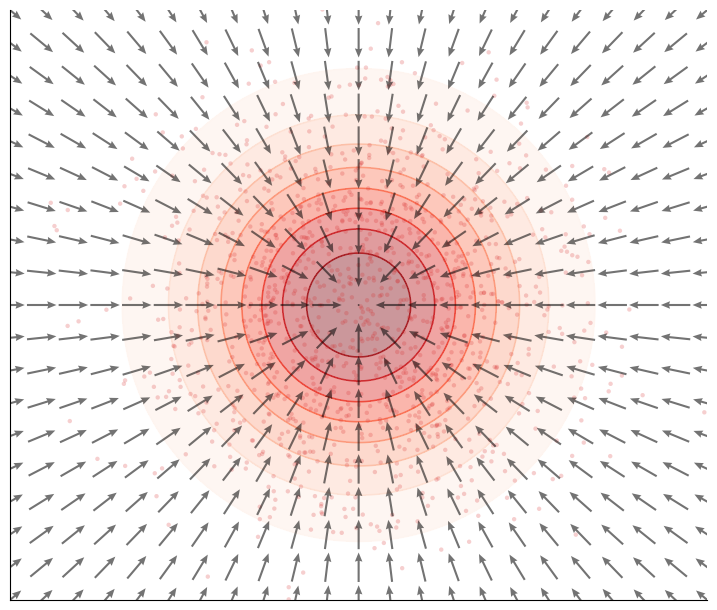

Pure diffusion snapshot with score field
Density: p_t(x) = N(mu, s_t^2 I)
Score:   grad_x log p_t(x) = -(x - mu) / s_t^2
SNAPSHOT_STEP = 100
t = 2.000
s_t = 0.784
Saved figure to: pure_diffusion_snapshot_with_score_field.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Pure diffusion snapshot with density contours + score field
#
# Pure diffusion:
#   x_{n+1} = x_n + sigma * sqrt(dt) * epsilon_n
#
# where:
#   epsilon_n ~ N(0, I_2)
#
# Since the initial cloud is Gaussian and diffusion noise is Gaussian,
# the density remains Gaussian:
#
#   p_t(x) = N(mu, s_t^2 I)
#
# Therefore:
#
#   grad_x log p_t(x) = -(x - mu) / s_t^2
#
# This score field points toward higher density.
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
RNG = np.random.default_rng(10)

# Diffusion simulation
N_PARTICLES = 1200
DT = 0.02
N_STEPS = 350
SIGMA = 0.55

# Initial Gaussian blob
START_CENTER = np.array([0.0, 0.0])
START_STD = 0.10

# Which time snapshot to plot
SNAPSHOT_STEP = 100

# Plot limits
X_LIM = (-2.6, 2.6)
Y_LIM = (-2.2, 2.2)

# Particle appearance
PARTICLE_SIZE = 10
PARTICLE_ALPHA = 0.22
PARTICLE_COLOR = "tab:red"

# Density contour settings
DENSITY_CMAP = "Reds"
DENSITY_ALPHA = 0.42
N_DENSITY_LEVELS = 9
DENSITY_LINE_ALPHA = 0.75
DENSITY_LINE_WIDTH = 1.2

# Density grid resolution
NX = 260
NY = 220

# Score field arrows
SHOW_SCORE_FIELD = True
NQX = 23
NQY = 19

SCORE_ARROW_COLOR = "black"
SCORE_ARROW_ALPHA = 0.55
SCORE_ARROW_WIDTH = 0.003
SCORE_ARROW_LENGTH = 0.22
SCORE_ARROW_HEADWIDTH = 3.6
SCORE_ARROW_HEADLENGTH = 4.4
SCORE_ARROW_HEADAXISLENGTH = 4.0
SCORE_ARROW_NORMALIZE = True

# Saving
SAVE_FIG = True
FIG_PATH = "pure_diffusion_snapshot_with_score_field.png"
DPI = 300


# -----------------------------
# 2. Simulate pure diffusion
# -----------------------------
def simulate_pure_diffusion(
    n_particles=1200,
    n_steps=350,
    dt=0.02,
    sigma=0.55,
    start_center=np.array([0.0, 0.0]),
    start_std=0.10,
):
    """
    Simulate pure 2D diffusion:

        x_{n+1} = x_n + sigma * sqrt(dt) * epsilon_n

    where:

        epsilon_n ~ N(0, I_2)
    """

    paths = np.zeros((n_particles, n_steps + 1, 2))

    # Initial dense Gaussian blob.
    paths[:, 0, :] = (
        start_center[None, :]
        + start_std * RNG.standard_normal((n_particles, 2))
    )

    for n in range(n_steps):
        eps = RNG.standard_normal((n_particles, 2))
        noise_step = sigma * np.sqrt(dt) * eps
        paths[:, n + 1, :] = paths[:, n, :] + noise_step

    return paths


paths = simulate_pure_diffusion(
    n_particles=N_PARTICLES,
    n_steps=N_STEPS,
    dt=DT,
    sigma=SIGMA,
    start_center=START_CENTER,
    start_std=START_STD,
)


# -----------------------------
# 3. Closed-form density and score
# -----------------------------
def theoretical_std(step_idx):
    """
    Per-coordinate standard deviation at time t.

    Initial variance:
        START_STD^2

    Diffusion variance added:
        SIGMA^2 * t

    where:
        t = step_idx * DT
    """

    t = step_idx * DT
    return np.sqrt(START_STD**2 + SIGMA**2 * t)


def gaussian_density(X, Y, step_idx):
    """
    Closed-form Gaussian density of the pure diffusion cloud.
    """

    std = theoretical_std(step_idx)
    var = std**2

    dx = X - START_CENTER[0]
    dy = Y - START_CENTER[1]
    r2 = dx**2 + dy**2

    density = np.exp(-0.5 * r2 / var) / (2.0 * np.pi * var)

    # Normalize only for plotting.
    density = density / density.max()

    return density


def score_field(X, Y, step_idx):
    """
    Score field:

        grad_x log p_t(x) = -(x - mu) / s_t^2

    for p_t(x) = N(mu, s_t^2 I).
    """

    std = theoretical_std(step_idx)
    var = std**2

    U = -(X - START_CENTER[0]) / var
    V = -(Y - START_CENTER[1]) / var

    return U, V


# -----------------------------
# 4. Build plotting grids
# -----------------------------
xs = np.linspace(X_LIM[0], X_LIM[1], NX)
ys = np.linspace(Y_LIM[0], Y_LIM[1], NY)
Xg, Yg = np.meshgrid(xs, ys)

density = gaussian_density(Xg, Yg, SNAPSHOT_STEP)

levels = np.linspace(0.08, 1.0, N_DENSITY_LEVELS)

# Sparse grid for score arrows
xq = np.linspace(X_LIM[0], X_LIM[1], NQX)
yq = np.linspace(Y_LIM[0], Y_LIM[1], NQY)
Xq, Yq = np.meshgrid(xq, yq)

Uq, Vq = score_field(Xq, Yq, SNAPSHOT_STEP)

if SCORE_ARROW_NORMALIZE:
    norm = np.sqrt(Uq**2 + Vq**2)
    Uq = Uq / (norm + 1e-12)
    Vq = Vq / (norm + 1e-12)

Uq_plot = SCORE_ARROW_LENGTH * Uq
Vq_plot = SCORE_ARROW_LENGTH * Vq


# -----------------------------
# 5. Plot helper
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# -----------------------------
# 6. Plot snapshot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 6.2))

# Density background
ax.contourf(
    Xg,
    Yg,
    density,
    levels=levels,
    cmap=DENSITY_CMAP,
    alpha=DENSITY_ALPHA,
    zorder=1,
)

ax.contour(
    Xg,
    Yg,
    density,
    levels=levels,
    cmap=DENSITY_CMAP,
    linewidths=DENSITY_LINE_WIDTH,
    alpha=DENSITY_LINE_ALPHA,
    zorder=2,
)

# Particles at snapshot time
cloud = paths[:, SNAPSHOT_STEP, :]

ax.scatter(
    cloud[:, 0],
    cloud[:, 1],
    s=PARTICLE_SIZE,
    c=PARTICLE_COLOR,
    alpha=PARTICLE_ALPHA,
    edgecolor="none",
    zorder=3,
)

# Score arrows: grad log p_t(x)
if SHOW_SCORE_FIELD:
    ax.quiver(
        Xq,
        Yq,
        Uq_plot,
        Vq_plot,
        color=SCORE_ARROW_COLOR,
        alpha=SCORE_ARROW_ALPHA,
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=SCORE_ARROW_WIDTH,
        headwidth=SCORE_ARROW_HEADWIDTH,
        headlength=SCORE_ARROW_HEADLENGTH,
        headaxislength=SCORE_ARROW_HEADAXISLENGTH,
        zorder=4,
    )

# Text labels
t = SNAPSHOT_STEP * DT

# ax.text(
#     0.04,
#     0.95,
#     rf"$p_t(x)$,  $t={t:.2f}$",
#     transform=ax.transAxes,
#     ha="left", 
#     va="top",
#     fontsize=17,
#     color="black",
# )

# ax.text(
#     0.04,
#     0.88,
#     r"arrows show $\nabla_x \log p_t(x)$",
#     transform=ax.transAxes,
#     ha="left",
#     va="top",
#     fontsize=14,
#     color="black",
# )

# ax.text(
#     0.04,
#     0.82,
#     r"score points toward higher density",
#     transform=ax.transAxes,
#     ha="left",
#     va="top",
#     fontsize=13,
#     color="black",
# )

clean_axes(ax)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig(FIG_PATH, dpi=DPI, bbox_inches="tight")

plt.show()


# -----------------------------
# 7. Print info
# -----------------------------
print("Pure diffusion snapshot with score field")
print("Density: p_t(x) = N(mu, s_t^2 I)")
print("Score:   grad_x log p_t(x) = -(x - mu) / s_t^2")
print(f"SNAPSHOT_STEP = {SNAPSHOT_STEP}")
print(f"t = {t:.3f}")
print(f"s_t = {theoretical_std(SNAPSHOT_STEP):.3f}")

if SAVE_FIG:
    print(f"Saved figure to: {FIG_PATH}")

# full toy Anderson reverse SDE simulation for your charged-particle system.

Important: in this 2D toy, we estimate the score
$$\nabla_x \log p_t(x)$$
from many forward particles using a Gaussian KDE. In real diffusion models, this score is not available and is learned by a neural network.

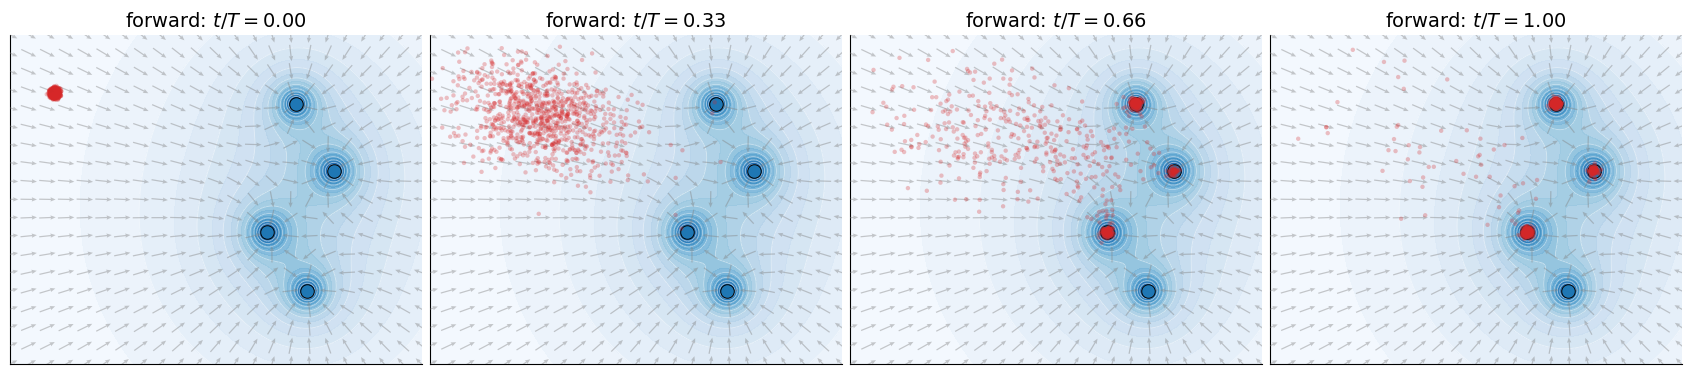

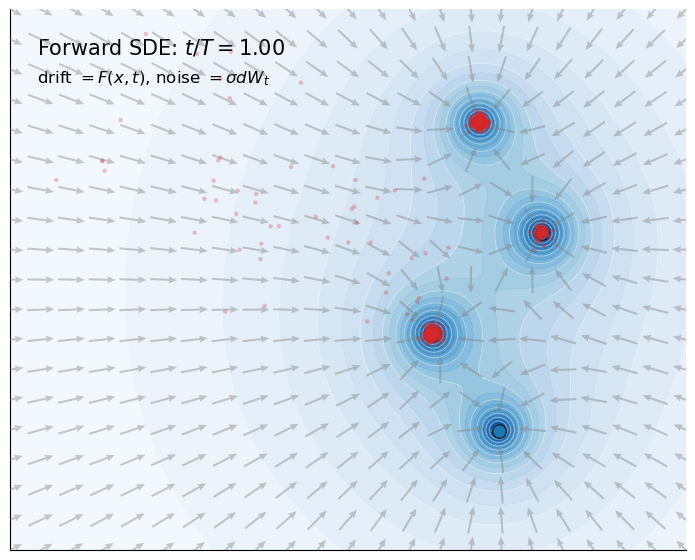

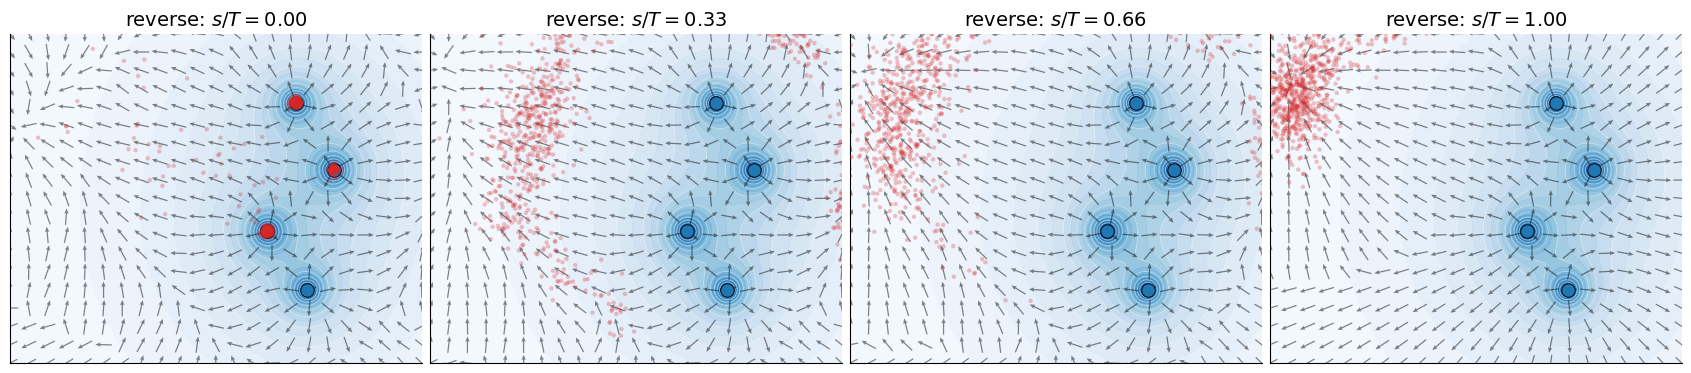

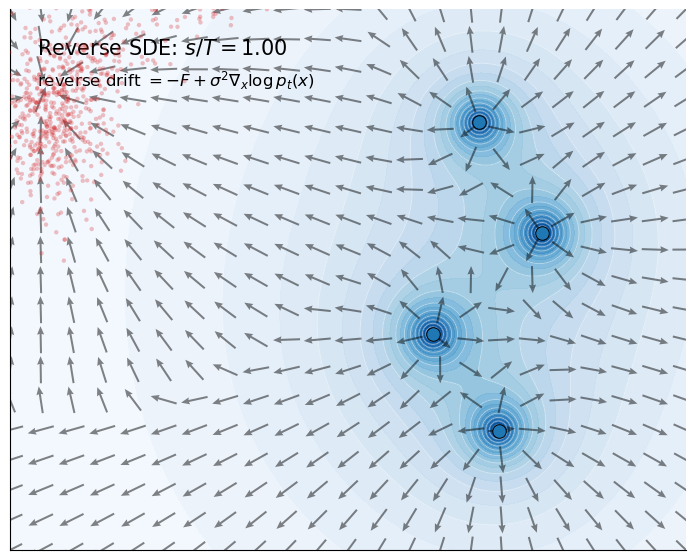

Charged-particle forward SDE + Anderson reverse SDE

Forward:
    x[n+1] = x[n] + dt F(x[n]) + sigma sqrt(dt) eps[n]

Reverse:
    x_rev[n+1] = x_rev[n] + dt[-F(x_rev[n]) + sigma^2 score_t(x_rev[n])] + sigma sqrt(dt) eps[n]

Score estimated by KDE from forward particle cloud:
    score_t(x) ≈ grad_x log p_t(x)

N_PARTICLES = 900
N_STEPS = 650
DT = 0.015
SIGMA = 0.24
SCORE_BANDWIDTH = 0.32
N_SCORE_REFERENCE = 450
Saved forward snapshots to: charged_forward_sde_snapshots.png
Saved forward animation GIF to: charged_forward_sde.gif
Saved reverse snapshots to: charged_reverse_sde_snapshots.png
Saved reverse animation GIF to: charged_reverse_sde_anderson.gif


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Charged-particle toy example:
# Forward SDE + Anderson reverse SDE
#
# Forward SDE:
#   dx = F(x,t) dt + sigma(t) dW_t
#
# Reverse-time SDE using a reverse clock:
#   dx = [-F(x,t) + sigma(t)^2 score_t(x)] ds + sigma(t) dWbar_s
#
# where:
#   score_t(x) = grad_x log p_t(x)
#
# In this toy code:
#   score_t(x) is estimated from the forward particle cloud using KDE.
#
# In real diffusion models:
#   score_t(x) is unknown and learned by a neural network.
#
# This version creates:
#   1. forward snapshots
#   2. forward movie
#   3. reverse snapshots
#   4. reverse movie
# ============================================================


# -----------------------------
# 1. Tunable settings
# -----------------------------
RNG = np.random.default_rng(7)

# Source-charge configuration
N_SOURCE_CHARGES = 4
SOURCE_SHAPE = "S"              # "S" or "triangle"
SOURCE_CENTER = np.array([1.25, 0.0])

# Initial positive particle cloud
START_POS = np.array([-2.35, 1.55])
START_STD = 0.035               # small spread; avoids perfect delta density

# SDE dynamics
DT = 0.015
N_STEPS = 650
SIGMA = 0.24                    # noise strength sigma(t), here constant
K_COULOMB = 1.0
SOFTENING_FORCE = 0.14
SOFTENING_POTENTIAL = 0.12
MAX_FORWARD_DRIFT_SPEED = 2.0
MAX_REVERSE_DRIFT_SPEED = 3.0
Q_SOURCE = -1.0

# Number of particles
N_PARTICLES = 900

# Score estimation by KDE
SCORE_BANDWIDTH = 0.32
N_SCORE_REFERENCE = 450
SCORE_EPS = 1e-12

# Plot limits
X_LIM = (-3.0, 3.0)
Y_LIM = (-2.4, 2.4)

# Potential grid resolution
NX = 300
NY = 240

# Arrow grid
NQX = 23
NQY = 19

# Forward force arrows
SHOW_FORWARD_FORCE_ARROWS = True
FORWARD_ARROW_COLOR = "grey"
FORWARD_ARROW_ALPHA = 0.42
FORWARD_ARROW_WIDTH = 0.003
FORWARD_ARROW_LENGTH = 0.24
FORWARD_ARROW_HEADWIDTH = 3.5
FORWARD_ARROW_HEADLENGTH = 4.2
FORWARD_ARROW_HEADAXISLENGTH = 3.8
FORWARD_ARROW_NORMALIZE = True

# Reverse drift arrows
SHOW_REVERSE_DRIFT_ARROWS = True
REVERSE_ARROW_COLOR = "black"
REVERSE_ARROW_ALPHA = 0.48
REVERSE_ARROW_WIDTH = 0.003
REVERSE_ARROW_LENGTH = 0.24
REVERSE_ARROW_HEADWIDTH = 3.5
REVERSE_ARROW_HEADLENGTH = 4.2
REVERSE_ARROW_HEADAXISLENGTH = 3.8
REVERSE_ARROW_NORMALIZE = True

# Particle cloud appearance
PARTICLE_SIZE = 10
PARTICLE_ALPHA = 0.28
PARTICLE_COLOR = "tab:red"

SOURCE_SIZE = 95

# Snapshot settings
SNAPSHOT_FRACTIONS = [0.0, 0.33, 0.66, 1.0]

# Animation settings
N_FRAMES = 170
FPS = 25
SHOW_ARROWS_IN_FORWARD_GIF = True
SHOW_ARROWS_IN_REVERSE_GIF = True

# Saving
SAVE_FORWARD_SNAPSHOT_PNG = True
SAVE_FORWARD_ANIMATION_GIF = True
SAVE_REVERSE_SNAPSHOT_PNG = True
SAVE_REVERSE_ANIMATION_GIF = True

FORWARD_SNAPSHOT_PNG_PATH = "charged_forward_sde_snapshots.png"
FORWARD_ANIMATION_GIF_PATH = "charged_forward_sde.gif"
REVERSE_SNAPSHOT_PNG_PATH = "charged_reverse_sde_snapshots.png"
REVERSE_ANIMATION_GIF_PATH = "charged_reverse_sde_anderson.gif"


# -----------------------------
# 2. Build source charges
# -----------------------------
def make_source_charges(shape="S", n=4, center=np.array([1.25, 0.0])):
    """
    Create fixed negative source charges.
    """

    if shape == "S":
        t = np.linspace(-np.pi, np.pi, n)
        x = 0.55 * np.sin(1.05 * t)
        y = 1.35 * t / np.pi
        charges = np.stack([x, y], axis=1)
        charges += 0.035 * RNG.standard_normal((n, 2))

    elif shape == "triangle":
        n1 = n // 3
        n2 = n // 3
        n3 = n - n1 - n2

        A = np.array([-0.65, -0.95])
        B = np.array([0.65, -0.95])
        C = np.array([0.00, 0.95])

        edge1 = np.linspace(A, B, n1, endpoint=False)
        edge2 = np.linspace(B, C, n2, endpoint=False)
        edge3 = np.linspace(C, A, n3, endpoint=False)

        charges = np.vstack([edge1, edge2, edge3])
        charges += 0.025 * RNG.standard_normal((n, 2))

    else:
        raise ValueError("shape must be 'S' or 'triangle'")

    return charges + center[None, :]


source_pos = make_source_charges(
    shape=SOURCE_SHAPE,
    n=N_SOURCE_CHARGES,
    center=SOURCE_CENTER
)


# -----------------------------
# 3. Physical force field
# -----------------------------
def force_on_positive_charge(x, source_positions):
    """
    Total attractive force on positive test charge(s).

    x can be:
        shape (2,)
        shape (B, 2)
    """

    x = np.asarray(x)

    if x.ndim == 1:
        r = source_positions - x[None, :]
        dist2 = np.sum(r**2, axis=1) + SOFTENING_FORCE**2
        dist3 = dist2 ** 1.5
        forces = K_COULOMB * r / dist3[:, None]
        return np.sum(forces, axis=0)

    if x.ndim == 2:
        r = source_positions[None, :, :] - x[:, None, :]
        dist2 = np.sum(r**2, axis=2) + SOFTENING_FORCE**2
        dist3 = dist2 ** 1.5
        forces = K_COULOMB * r / dist3[:, :, None]
        return np.sum(forces, axis=1)

    raise ValueError("x must have shape (2,) or (B, 2)")


def cap_vectors(V, max_norm):
    """
    Cap vector norms for numerical stability.

    V can be shape (2,) or (B, 2).
    """

    V = np.asarray(V)

    if V.ndim == 1:
        norm = np.linalg.norm(V)
        if norm > max_norm:
            return V / norm * max_norm
        return V

    norms = np.linalg.norm(V, axis=1, keepdims=True)
    scale = np.minimum(1.0, max_norm / (norms + 1e-12))
    return V * scale


# -----------------------------
# 4. Forward SDE simulation
# -----------------------------
def simulate_forward_sde(
    n_particles=900,
    n_steps=650,
    dt=0.015,
    sigma=0.24,
    start_pos=np.array([-2.35, 1.55]),
    start_std=0.035,
):
    """
    Forward Euler-Maruyama:

        x_{n+1} = x_n + dt F(x_n) + sigma sqrt(dt) epsilon_n

    where:

        epsilon_n ~ N(0, I_2)
    """

    paths = np.zeros((n_particles, n_steps + 1, 2))

    paths[:, 0, :] = (
        start_pos[None, :]
        + start_std * RNG.standard_normal((n_particles, 2))
    )

    for n in range(n_steps):
        x = paths[:, n, :]

        F = force_on_positive_charge(x, source_pos)
        F = cap_vectors(F, MAX_FORWARD_DRIFT_SPEED)

        eps = RNG.standard_normal((n_particles, 2))
        noise = sigma * np.sqrt(dt) * eps

        paths[:, n + 1, :] = x + dt * F + noise

    return paths


forward_paths = simulate_forward_sde(
    n_particles=N_PARTICLES,
    n_steps=N_STEPS,
    dt=DT,
    sigma=SIGMA,
    start_pos=START_POS,
    start_std=START_STD,
)


# -----------------------------
# 5. KDE score estimator
# -----------------------------
def choose_reference_cloud(cloud, n_ref):
    """
    Subsample reference particles for KDE score estimation.
    """

    if cloud.shape[0] <= n_ref:
        return cloud

    idx = RNG.choice(cloud.shape[0], size=n_ref, replace=False)
    return cloud[idx]


def kde_score(query_points, reference_points, bandwidth=0.32):
    """
    Estimate score:

        score(x) = grad_x log p(x)

    using Gaussian KDE:

        p(x) ≈ (1/N) sum_i exp(-||x-y_i||^2 / (2h^2))

    Then:

        grad_x log p(x)
        =
        sum_i w_i (y_i - x) / h^2
        -------------------------
              sum_i w_i
    """

    X = np.asarray(query_points)
    Y = np.asarray(reference_points)

    if X.ndim == 1:
        X = X[None, :]

    h2 = bandwidth**2

    diff = Y[None, :, :] - X[:, None, :]          # (B, R, 2)
    dist2 = np.sum(diff**2, axis=2)               # (B, R)

    weights = np.exp(-0.5 * dist2 / h2)           # (B, R)

    denom = np.sum(weights, axis=1, keepdims=True) + SCORE_EPS
    numer = np.sum(weights[:, :, None] * diff, axis=1) / h2

    score = numer / denom

    return score


# -----------------------------
# 6. Reverse SDE simulation using Anderson drift
# -----------------------------
def simulate_reverse_sde(
    forward_paths,
    dt=0.015,
    sigma=0.24,
    bandwidth=0.32,
    n_score_reference=450,
):
    """
    Reverse Euler-Maruyama with reverse clock.

    Forward process produced:
        p_0, p_1, ..., p_N

    Reverse starts from:
        x_0^rev ~ p_N

    At reverse step n, corresponding forward time index is:
        k = N - n

    Reverse update:
        x_{n+1} = x_n
                  + dt[-F(x_n) + sigma^2 score_k(x_n)]
                  + sigma sqrt(dt) epsilon_n

    where:
        score_k(x) ≈ grad_x log p_k(x).
    """

    n_particles = forward_paths.shape[0]
    n_steps = forward_paths.shape[1] - 1

    reverse_paths = np.zeros_like(forward_paths)

    # Start reverse process from the final forward cloud p_T.
    reverse_paths[:, 0, :] = forward_paths[:, -1, :]

    for n in range(n_steps):
        x = reverse_paths[:, n, :]

        # Matching forward time: T -> 0
        forward_idx = n_steps - n
        reference_cloud = choose_reference_cloud(
            forward_paths[:, forward_idx, :],
            n_score_reference
        )

        # Physical force at current reverse particles
        F = force_on_positive_charge(x, source_pos)
        F = cap_vectors(F, MAX_FORWARD_DRIFT_SPEED)

        # Score of forward density at matching time
        score = kde_score(
            query_points=x,
            reference_points=reference_cloud,
            bandwidth=bandwidth
        )

        # Anderson reverse drift with reverse clock:
        #   b_reverse = -F + sigma^2 score
        reverse_drift = -F + (sigma**2) * score
        reverse_drift = cap_vectors(reverse_drift, MAX_REVERSE_DRIFT_SPEED)

        eps = RNG.standard_normal((n_particles, 2))
        noise = sigma * np.sqrt(dt) * eps

        reverse_paths[:, n + 1, :] = x + dt * reverse_drift + noise

    return reverse_paths


reverse_paths = simulate_reverse_sde(
    forward_paths=forward_paths,
    dt=DT,
    sigma=SIGMA,
    bandwidth=SCORE_BANDWIDTH,
    n_score_reference=N_SCORE_REFERENCE,
)


# -----------------------------
# 7. Potential grid for background
# -----------------------------
def compute_potential_grid(
    source_positions,
    q_source=-1.0,
    k_coulomb=1.0,
    eps=0.12,
    xlim=(-3.0, 3.0),
    ylim=(-2.4, 2.4),
    nx=300,
    ny=240,
):
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    phi = np.zeros_like(X, dtype=float)

    for i in range(source_positions.shape[0]):
        dx = X - source_positions[i, 0]
        dy = Y - source_positions[i, 1]
        dist = np.sqrt(dx**2 + dy**2 + eps**2)
        phi += k_coulomb * q_source / dist

    return X, Y, phi


Xg, Yg, phi = compute_potential_grid(
    source_positions=source_pos,
    q_source=Q_SOURCE,
    k_coulomb=K_COULOMB,
    eps=SOFTENING_POTENTIAL,
    xlim=X_LIM,
    ylim=Y_LIM,
    nx=NX,
    ny=NY,
)

# Negative charges produce negative potential.
# Plot -phi so attractive wells look darker.
phi_display = -phi


# -----------------------------
# 8. Arrow fields
# -----------------------------
def compute_forward_force_grid():
    """
    Compute the forward physical force field F(x) on a sparse grid.
    """

    xs = np.linspace(X_LIM[0], X_LIM[1], NQX)
    ys = np.linspace(Y_LIM[0], Y_LIM[1], NQY)
    Xq, Yq = np.meshgrid(xs, ys)

    query = np.stack([Xq.ravel(), Yq.ravel()], axis=1)

    F = force_on_positive_charge(query, source_pos)
    F = cap_vectors(F, MAX_FORWARD_DRIFT_SPEED)

    U = F[:, 0].reshape(Xq.shape)
    V = F[:, 1].reshape(Yq.shape)

    if FORWARD_ARROW_NORMALIZE:
        norm = np.sqrt(U**2 + V**2)
        U = U / (norm + 1e-12)
        V = V / (norm + 1e-12)

    U_plot = FORWARD_ARROW_LENGTH * U
    V_plot = FORWARD_ARROW_LENGTH * V

    return Xq, Yq, U_plot, V_plot


def compute_reverse_drift_grid(forward_idx):
    """
    Compute the reverse drift field:

        b_reverse(x,t) = -F(x,t) + sigma^2 score_t(x)

    on a sparse grid.
    """

    xs = np.linspace(X_LIM[0], X_LIM[1], NQX)
    ys = np.linspace(Y_LIM[0], Y_LIM[1], NQY)
    Xq, Yq = np.meshgrid(xs, ys)

    query = np.stack([Xq.ravel(), Yq.ravel()], axis=1)

    F = force_on_positive_charge(query, source_pos)
    F = cap_vectors(F, MAX_FORWARD_DRIFT_SPEED)

    reference_cloud = choose_reference_cloud(
        forward_paths[:, forward_idx, :],
        N_SCORE_REFERENCE
    )

    score = kde_score(
        query_points=query,
        reference_points=reference_cloud,
        bandwidth=SCORE_BANDWIDTH
    )

    reverse_drift = -F + (SIGMA**2) * score
    reverse_drift = cap_vectors(reverse_drift, MAX_REVERSE_DRIFT_SPEED)

    U = reverse_drift[:, 0].reshape(Xq.shape)
    V = reverse_drift[:, 1].reshape(Yq.shape)

    if REVERSE_ARROW_NORMALIZE:
        norm = np.sqrt(U**2 + V**2)
        U = U / (norm + 1e-12)
        V = V / (norm + 1e-12)

    U_plot = REVERSE_ARROW_LENGTH * U
    V_plot = REVERSE_ARROW_LENGTH * V

    return Xq, Yq, U_plot, V_plot


# Precompute forward arrows once because they do not depend on time.
Xq_fwd, Yq_fwd, Uq_fwd, Vq_fwd = compute_forward_force_grid()


# -----------------------------
# 9. Plot helpers
# -----------------------------
def clean_axes(ax):
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_background(ax):
    ax.contourf(
        Xg,
        Yg,
        phi_display,
        levels=30,
        cmap="Blues",
        alpha=0.92,
        zorder=1,
    )

    ax.contour(
        Xg,
        Yg,
        phi_display,
        levels=12,
        colors="white",
        linewidths=0.6,
        alpha=0.55,
        zorder=2,
    )

    ax.scatter(
        source_pos[:, 0],
        source_pos[:, 1],
        s=SOURCE_SIZE,
        c="tab:blue",
        edgecolor="black",
        linewidth=0.7,
        zorder=5,
    )

    clean_axes(ax)


def draw_forward_force_arrows(ax):
    if not SHOW_FORWARD_FORCE_ARROWS:
        return

    ax.quiver(
        Xq_fwd,
        Yq_fwd,
        Uq_fwd,
        Vq_fwd,
        color=FORWARD_ARROW_COLOR,
        alpha=FORWARD_ARROW_ALPHA,
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=FORWARD_ARROW_WIDTH,
        headwidth=FORWARD_ARROW_HEADWIDTH,
        headlength=FORWARD_ARROW_HEADLENGTH,
        headaxislength=FORWARD_ARROW_HEADAXISLENGTH,
        zorder=4,
    )


def draw_reverse_drift_arrows(ax, forward_idx):
    if not SHOW_REVERSE_DRIFT_ARROWS:
        return

    Xq, Yq, Uq, Vq = compute_reverse_drift_grid(forward_idx)

    ax.quiver(
        Xq,
        Yq,
        Uq,
        Vq,
        color=REVERSE_ARROW_COLOR,
        alpha=REVERSE_ARROW_ALPHA,
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=REVERSE_ARROW_WIDTH,
        headwidth=REVERSE_ARROW_HEADWIDTH,
        headlength=REVERSE_ARROW_HEADLENGTH,
        headaxislength=REVERSE_ARROW_HEADAXISLENGTH,
        zorder=4,
    )


# -----------------------------
# 10. Forward snapshots
# -----------------------------
def plot_forward_snapshots():
    snapshot_ids = [int(frac * N_STEPS) for frac in SNAPSHOT_FRACTIONS]

    fig, axes = plt.subplots(
        1,
        len(snapshot_ids),
        figsize=(4.2 * len(snapshot_ids), 4.2),
        constrained_layout=True,
    )

    if len(snapshot_ids) == 1:
        axes = [axes]

    for ax, idx, frac in zip(axes, snapshot_ids, SNAPSHOT_FRACTIONS):
        draw_background(ax)
        draw_forward_force_arrows(ax)

        cloud = forward_paths[:, idx, :]

        ax.scatter(
            cloud[:, 0],
            cloud[:, 1],
            s=PARTICLE_SIZE,
            c=PARTICLE_COLOR,
            alpha=PARTICLE_ALPHA,
            edgecolor="none",
            zorder=6,
        )

        ax.set_title(
            rf"forward: $t/T={frac:.2f}$",
            fontsize=14,
        )

    if SAVE_FORWARD_SNAPSHOT_PNG:
        plt.savefig(FORWARD_SNAPSHOT_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_forward_snapshots()


# -----------------------------
# 11. Forward animation
# -----------------------------
def animate_forward_sde():
    fig, ax = plt.subplots(figsize=(8, 6))

    frame_ids = np.linspace(0, N_STEPS, N_FRAMES).astype(int)

    def update(frame_number):
        ax.clear()

        idx = frame_ids[frame_number]

        draw_background(ax)

        if SHOW_ARROWS_IN_FORWARD_GIF:
            draw_forward_force_arrows(ax)

        cloud = forward_paths[:, idx, :]

        ax.scatter(
            cloud[:, 0],
            cloud[:, 1],
            s=PARTICLE_SIZE,
            c=PARTICLE_COLOR,
            alpha=PARTICLE_ALPHA,
            edgecolor="none",
            zorder=6,
        )

        ax.text(
            0.04,
            0.95,
            rf"Forward SDE: $t/T={idx / N_STEPS:.2f}$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=15,
            color="black",
        )

        ax.text(
            0.04,
            0.89,
            r"drift $= F(x,t)$, noise $= \sigma dW_t$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            color="black",
        )

        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=N_FRAMES,
        interval=35,
        blit=False,
    )

    plt.tight_layout()

    if SAVE_FORWARD_ANIMATION_GIF:
        anim.save(FORWARD_ANIMATION_GIF_PATH, writer=PillowWriter(fps=FPS))

    plt.show()

    return anim


anim_forward = animate_forward_sde()


# -----------------------------
# 12. Reverse snapshots
# -----------------------------
def plot_reverse_snapshots():
    snapshot_ids = [int(frac * N_STEPS) for frac in SNAPSHOT_FRACTIONS]

    fig, axes = plt.subplots(
        1,
        len(snapshot_ids),
        figsize=(4.2 * len(snapshot_ids), 4.2),
        constrained_layout=True,
    )

    if len(snapshot_ids) == 1:
        axes = [axes]

    for ax, rev_idx, frac in zip(axes, snapshot_ids, SNAPSHOT_FRACTIONS):
        draw_background(ax)

        # Reverse index rev_idx corresponds to forward time N_STEPS - rev_idx.
        forward_idx = max(N_STEPS - rev_idx, 0)

        draw_reverse_drift_arrows(ax, forward_idx)

        cloud = reverse_paths[:, rev_idx, :]

        ax.scatter(
            cloud[:, 0],
            cloud[:, 1],
            s=PARTICLE_SIZE,
            c=PARTICLE_COLOR,
            alpha=PARTICLE_ALPHA,
            edgecolor="none",
            zorder=6,
        )

        ax.set_title(
            rf"reverse: $s/T={frac:.2f}$",
            fontsize=14,
        )

    if SAVE_REVERSE_SNAPSHOT_PNG:
        plt.savefig(REVERSE_SNAPSHOT_PNG_PATH, dpi=300, bbox_inches="tight")

    plt.show()


plot_reverse_snapshots()


# -----------------------------
# 13. Reverse animation
# -----------------------------
def animate_reverse_sde():
    fig, ax = plt.subplots(figsize=(8, 6))

    frame_ids = np.linspace(0, N_STEPS, N_FRAMES).astype(int)

    def update(frame_number):
        ax.clear()

        rev_idx = frame_ids[frame_number]
        forward_idx = max(N_STEPS - rev_idx, 0)

        draw_background(ax)

        if SHOW_ARROWS_IN_REVERSE_GIF:
            draw_reverse_drift_arrows(ax, forward_idx)

        cloud = reverse_paths[:, rev_idx, :]

        ax.scatter(
            cloud[:, 0],
            cloud[:, 1],
            s=PARTICLE_SIZE,
            c=PARTICLE_COLOR,
            alpha=PARTICLE_ALPHA,
            edgecolor="none",
            zorder=6,
        )

        ax.text(
            0.04,
            0.95,
            rf"Reverse SDE: $s/T={rev_idx / N_STEPS:.2f}$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=15,
            color="black",
        )

        ax.text(
            0.04,
            0.89,
            r"reverse drift $= -F + \sigma^2 \nabla_x \log p_t(x)$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            color="black",
        )

        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=N_FRAMES,
        interval=35,
        blit=False,
    )

    plt.tight_layout()

    if SAVE_REVERSE_ANIMATION_GIF:
        anim.save(REVERSE_ANIMATION_GIF_PATH, writer=PillowWriter(fps=FPS))

    plt.show()

    return anim


anim_reverse = animate_reverse_sde()


# -----------------------------
# 14. Print info
# -----------------------------
print("Charged-particle forward SDE + Anderson reverse SDE")
print()
print("Forward:")
print("    x[n+1] = x[n] + dt F(x[n]) + sigma sqrt(dt) eps[n]")
print()
print("Reverse:")
print("    x_rev[n+1] = x_rev[n] + dt[-F(x_rev[n]) + sigma^2 score_t(x_rev[n])] + sigma sqrt(dt) eps[n]")
print()
print("Score estimated by KDE from forward particle cloud:")
print("    score_t(x) ≈ grad_x log p_t(x)")
print()
print(f"N_PARTICLES = {N_PARTICLES}")
print(f"N_STEPS = {N_STEPS}")
print(f"DT = {DT}")
print(f"SIGMA = {SIGMA}")
print(f"SCORE_BANDWIDTH = {SCORE_BANDWIDTH}")
print(f"N_SCORE_REFERENCE = {N_SCORE_REFERENCE}")

if SAVE_FORWARD_SNAPSHOT_PNG:
    print(f"Saved forward snapshots to: {FORWARD_SNAPSHOT_PNG_PATH}")

if SAVE_FORWARD_ANIMATION_GIF:
    print(f"Saved forward animation GIF to: {FORWARD_ANIMATION_GIF_PATH}")

if SAVE_REVERSE_SNAPSHOT_PNG:
    print(f"Saved reverse snapshots to: {REVERSE_SNAPSHOT_PNG_PATH}")

if SAVE_REVERSE_ANIMATION_GIF:
    print(f"Saved reverse animation GIF to: {REVERSE_ANIMATION_GIF_PATH}")